***HOMEWORK 3***

We are going to use the Titanic dataset from HW1 again, only this time we'll be doing some deeper data cleaning and analysis.

**Learning Goals**
* Identifying missing/null/bad data
* How to handle missing data
* The "effect" of your data cleaning on summative statistics
* Practice querying/subsetting data

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:

titanic = pd.read_csv(
    'https://github.com/MainakRepositor/'
    'Datasets/blob/master/Titanic.csv?raw=True'
).set_index('PassengerId')

**CODE**
Change the Pclass and Sex columns to be categorical

In [3]:
#change the Pclass to be categorical
titanic['Pclass'] = pd.Categorical(titanic['Pclass'])
#change the Sex column to be categorical
titanic['Sex'] = pd.Categorical(titanic['Sex'])

**CODE**
Identify which columns that have missing data and how much. Look for both NaN and ZERO in the numerical columns

**ANALYSIS**
How many nulls are in the columns Age, Cabin, and Embarked. How many Zeros in the fare column.

* 177 missing age
* 15 fares of zero
* 687 missing Cabin
* 2 missing Embarked

In [5]:
# are there any missing values?
titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    category
 2   Name      891 non-null    object  
 3   Sex       891 non-null    category
 4   Age       714 non-null    float64 
 5   SibSp     891 non-null    int64   
 6   Parch     891 non-null    int64   
 7   Ticket    891 non-null    object  
 8   Fare      891 non-null    float64 
 9   Cabin     204 non-null    object  
 10  Embarked  889 non-null    object  
dtypes: category(2), float64(2), int64(3), object(4)
memory usage: 71.6+ KB


In [4]:
# ALTERNATE METHOD:
missing_data = titanic.isnull().sum()
zero_in_numerical_columns = (titanic.select_dtypes(include=['float64', 'int64']) == 0).sum()
print(missing_data)
print(zero_in_numerical_columns)

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64
Survived    549
Age           0
SibSp       608
Parch       678
Fare         15
dtype: int64


**CODE**

* Use a dataframe selector to list the rows with missing AGE values

* Run some summary statistics to see if these missing values are skewed towards sex/Pclass/fare

**ANALYSIS**
Are the missing age passengers skewed towards certain sex/Pclass/fare

* skews towards class 3 and male
* several outlier high fares, most (75%) are below 24, despite the mean being 22


In [78]:
#get the rows from titanic where age is missing or zero
missing_age = titanic[titanic['Age'].isnull() | (titanic['Age'] == 0)]
missing_age.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q


In [79]:
#describe all the categorical columns in the missing_age dataframe
missing_age.describe(include=['category'])

,Pclass,Sex
count,177,177
unique,3,2
top,3,male
freq,136,124


In [80]:
#get the count of classes in Pclass
missing_age['Pclass'].value_counts()


Pclass
3    136
1     30
2     11
Name: count, dtype: int64

In [81]:
missing_age['Sex'].value_counts()

Sex
male      124
female     53
Name: count, dtype: int64

In [82]:
#get summary statistics on missing_age fare column
missing_age['Fare'].describe()

count    177.000000
mean      22.158567
std       31.874608
min        0.000000
25%        7.750000
50%        8.050000
75%       24.150000
max      227.525000
Name: Fare, dtype: float64

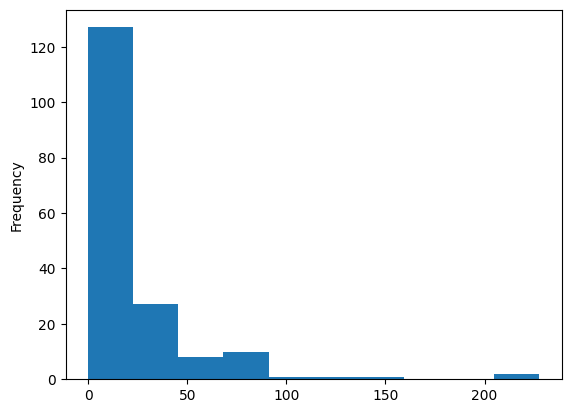

In [83]:
#plot the histogram of missing_age fare column
import matplotlib.pyplot as plt
missing_age['Fare'].plot(kind='hist')
plt.show()


**CODE**

We need to handle the missing ages, then analyze the results of our cleaning.

* Get summary statistics on age column

* Use two several methods to fill the NaN age values, then analyze the results of our choices. 

    * Use fillna with either bfill or ffill to fill the values. 

    * Use assign to replace NaN with the mean or median age.

* Try at least 2 of these filling methods and compare the summary statistics that result. You may need to make some copies of the titanic dataframe before filling.

**ANALYSIS**
Was there any noticeable difference in the summative statistics for either method you chose?

A: the standard deviation went down slightly when using the mean/median, which is to be expected

In [84]:
# get summary statistics on titanic AGE column
titanic['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [85]:
titanic_ffill = titanic.fillna(method='ffill')
titanic_ffill['Age'].describe()

count    891.00000
mean      29.58156
std       14.55459
min        0.42000
25%       20.00000
50%       28.00000
75%       38.00000
max       80.00000
Name: Age, dtype: float64

In [86]:
titanic_mean = titanic.assign(
    Age=lambda x: x.Age.fillna(x.Age.mean())
)
titanic_mean['Age'].describe()

count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: Age, dtype: float64

**CODE**

Now that we've handled the missing Age's, lets do some more analysis 

* Using groupby and agg, get the min/max/mean Fare grouped by Sex

* Using groupby and agg, get the min/max/mean Fare grouped by Pclass

**ANALYSIS**
Does anything stand out from this analysis? Can you tell which class was "higher?" Do men or women pay more?

* Clearly Pclass1 is highest cost, followed by 2 and then 3 has the lowest mean fare
* Females seems to pay higher fares as well

In [87]:
#using groupby, get the mean age of each Pclass in the titanic dataset
titanic.groupby('Pclass')['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [88]:
titanic.groupby('Pclass')['Fare'].agg(['min', 'max', 'mean'])

,min,max,mean
Pclass,,,
1,0.0,512.3292,84.154687
2,0.0,73.5000,20.662183
3,0.0,69.5500,13.675550


In [89]:
titanic.groupby('Sex')['Fare'].agg(['min', 'max', 'mean'])

,min,max,mean
Sex,,,
female,6.75,512.3292,44.479818
male,0.00,512.3292,25.523893


**CODE**
List the rows that have a fare of zero, then replace them with the median fare. Then re-run the male/female Fare comparison again

**ANALYSIS**
Was there something that stood out about the list of passengers whose fare was 0? Did filling it with the mean change the Sex fare comparison

A: The list (15) was ALL MALE. Updating it to the median changed the mean slightly but didnt have any significant effect

In [90]:
#list the rows with a fare of zero
titanic[titanic['Fare'] == 0]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S
264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S
272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S
278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S
303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S
414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,NaN,S
467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,NaN,S
482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,NaN,S
598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S


In [93]:
titanic[179:180]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,14.4542,NaN,S


In [92]:
#replace the zero fare with the median fare
titanic['Fare'] = titanic['Fare'].replace(0, titanic['Fare'].median())

In [94]:
titanic.groupby('Sex')['Fare'].agg(['min', 'max', 'mean'])

,min,max,mean
Sex,,,
female,6.7500,512.3292,44.479818
male,4.0125,512.3292,25.899653


**CODE**

Finally, lets create some bins for Fare and see how many are in there.

* Using pd.cut, create a new column fare_bracket that puts fares into a 'low' 'medium' 'high' of EVEN RANGE

* Using groupby and agg, get the min/max/avg Fare for each fare_bracket

* Get the row count for each fare_bracket

* List the rows in the 'high' bracket

**ANALYSIS**
Does there appear to be outliers? Would you suggest excluding them?

A: Yes there are only 3 fares in the high bracket, all with a price of 512.3292. The max of the 'medium' bracket is only 263. I would likely exclude those rows on Fare analysis.

In [95]:
#using cut, create a new column called fare_bracket that groups the fare into 3 bins low medium high
titanic['fare_bracket'] = pd.cut(
    titanic['Fare'], bins=3, labels=['low', 'medium', 'high']
)

In [96]:
#using groupby and agg get the min/max/mean of fare_bracket
titanic.groupby('fare_bracket')['Fare'].agg(['min', 'max', 'mean'])

,min,max,mean
fare_bracket,,,
low,4.0125,164.8667,26.779095
medium,211.3375,263.0000,238.187253
high,512.3292,512.3292,512.329200


In [98]:
#get fare_bracket value counts
titanic['fare_bracket'].value_counts()

fare_bracket
low       871
medium     17
high        3
Name: count, dtype: int64

In [99]:
#list the high fare_bracket rows
titanic[titanic['fare_bracket'] == 'high']

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,fare_bracket
PassengerId,,,,,,,,,,,,
259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,high
680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,high
738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,high
